## PREDICTING HOUSE PRICES: A REGRESSION EXAMPLE ##

Dataset (the California Housing Price dataset)

In [54]:
import random
import numpy as np
import tensorflow as tf
import os

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [55]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version='large')
)

print(test_data.shape)
print(train_data.shape)

(4128, 8)
(16512, 8)


Preparing the data

In [56]:
#Normalizing the data
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

In [57]:
#Scaling the target
y_train = train_targets / 100000
y_test = test_targets / 100000

Building the model

In [58]:
import keras
from keras import layers
def get_model():
    model = keras.Sequential(
        [
        layers.Dense(128, activation = 'relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1)
        ]
    )
    
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=0.001),
        loss = 'mean_squared_error',
        metrics = ['mean_absolute_error']
    )
    
    return model

K-fold validation

In [60]:

k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_mae_histories = []

for i in range(k):
    print(f'Processing fold #{i + 1}')
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis = 0
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1 ) * num_val_samples : ]],
        axis = 0
    )
    
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs = num_epochs,
        batch_size=16,
        verbose = 0,
    )
    mae_history = history.history['val_mean_absolute_error']
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [61]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

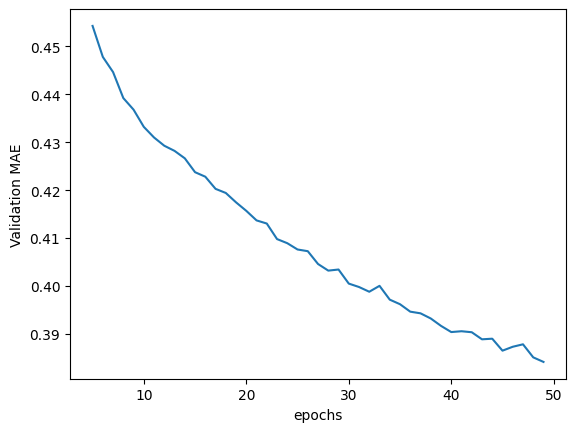

In [63]:
#plotting validation score
import matplotlib.pyplot as plt

truncated_mae_history = average_mae_history[5:]
epochs = range(5, len(truncated_mae_history) + 5)
plt.plot(epochs, truncated_mae_history)
plt.xlabel('epochs')
plt.ylabel('Validation MAE')
plt.show()

In [64]:
#Training the final model
model = get_model()
model.fit(x_train, y_train, epochs = 30, batch_size=16, verbose = 0)
test_mse, test_mae = model.evaluate(x_test, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3375 - mean_absolute_error: 0.4033


 MAE: 0.403
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step


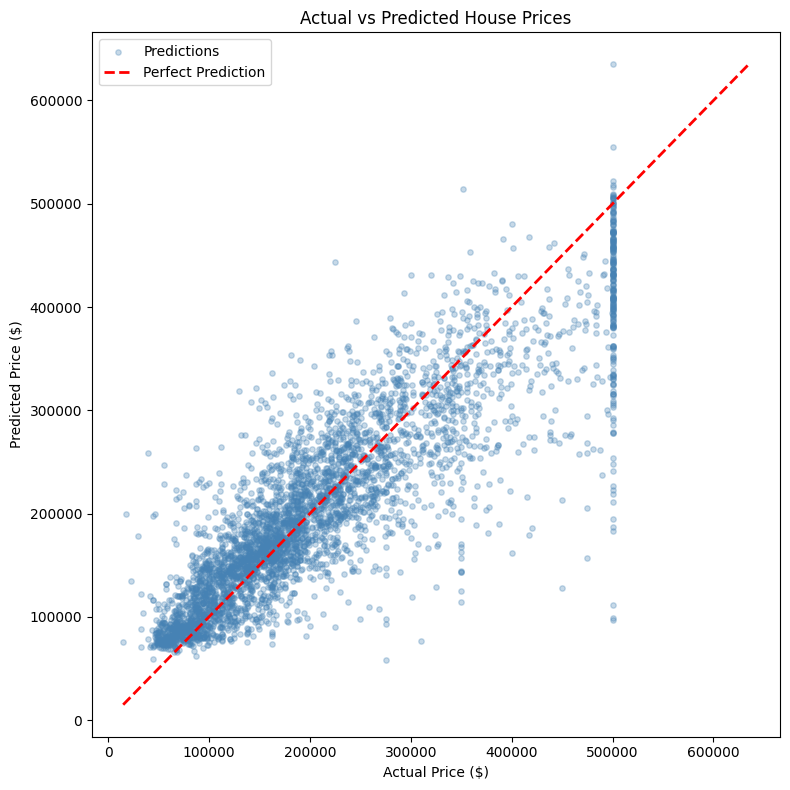

In [68]:
print(f' MAE: {round(test_mae, 3)}')
predictions = model.predict(x_test).flatten() * 100000
actuals = test_targets

plt.figure(figsize=(8, 8))

# Scatter: actual vs predicted
plt.scatter(actuals, predictions, alpha=0.3, s=15, color='steelblue', label='Predictions')

# Perfect prediction line
min_val = min(actuals.min(), predictions.min())
max_val = max(actuals.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

```The California Housing dataset itself caps all target values at $500,000. This is a known quirk of the dataset - any house that actually sold for more than $500k was clipped to exactly $500,000 during data collection. That's why you see a hella ammount of 5000000 predictions.```